# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from xgboost import XGBRegressor

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
df = df.copy()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 203.7 KB


In [5]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


In [6]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


### 2.2 Dividir en train y test

In [7]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### 2.3. Distribución target

<Axes: >

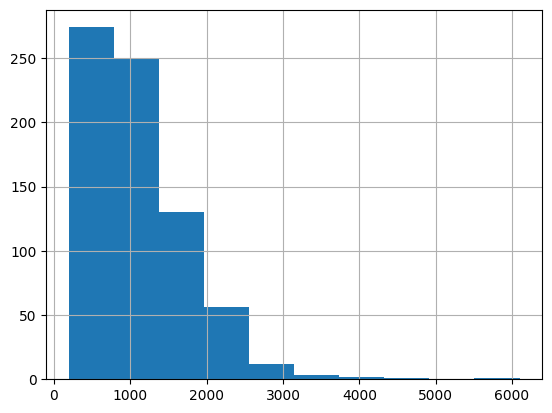

In [8]:
train_set["Price_in_euros"].hist()

### 2.4 Análisis de variables categóricas

In [9]:
train_set.Company.value_counts()

Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Microsoft      3
Samsung        3
Xiaomi         3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64

In [10]:
train_set.Product.value_counts()

Product
XPS 13                                       20
Inspiron 3567                                17
ProBook 450                                  12
250 G6                                       12
EliteBook 840                                11
                                             ..
FX502VM-DM105T (i7-6700HQ/8GB/1TB/GeForce     1
GE72 Apache                                   1
Omen 15-ce006nv                               1
14-am079na (N3710/8GB/2TB/W10)                1
Thinkpad T470p                                1
Name: count, Length: 408, dtype: int64

In [11]:
train_set.Product.nunique()

408

In [12]:
train_set.TypeName.value_counts()

TypeName
Notebook              412
Gaming                113
Ultrabook             113
2 in 1 Convertible     62
Netbook                16
Workstation            13
Name: count, dtype: int64

In [13]:
train_set.Cpu.value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       100
Intel Core i7 7700HQ 2.8GHz       82
Intel Core i7 7500U 2.7GHz        77
Intel Core i5 8250U 1.6GHz        46
Intel Core i5 6200U 2.3GHz        40
                                ... 
Intel Core i5 7500U 2.7GHz         1
Intel Core i3 6100U 2.1GHz         1
Intel Core M 1.1GHz                1
Intel Xeon E3-1535M v5 2.9GHz      1
AMD E-Series 6110 1.5GHz           1
Name: count, Length: 93, dtype: int64

In [14]:
train_set.Cpu.nunique()

93

In [15]:
train_set.Ram.value_counts()

Ram
8GB     340
4GB     217
16GB    112
6GB      20
12GB     18
2GB      15
32GB      6
64GB      1
Name: count, dtype: int64

In [16]:
train_set.ScreenResolution.value_counts()

ScreenResolution
Full HD 1920x1080                                280
1366x768                                         170
IPS Panel Full HD 1920x1080                      130
Full HD / Touchscreen 1920x1080                   26
IPS Panel Full HD / Touchscreen 1920x1080         25
1600x900                                          14
Quad HD+ / Touchscreen 3200x1800                  10
IPS Panel 4K Ultra HD / Touchscreen 3840x2160      7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
Touchscreen 1366x768                               5
IPS Panel 4K Ultra HD 3840x2160                    5
4K Ultra HD / Touchscreen 3840x2160                5
1440x900                                           4
Touchscreen 2560x1440                              4
IPS Panel 1366x768                                 4
IPS Panel Retina Display 2560x1600                 3
IPS Panel 2560x1440                                3
IPS Panel Retina Display 2304x1440                 3
4K Ultra HD 3840x2160        

In [17]:
train_set.ScreenResolution.nunique()

33

In [18]:
train_set.Memory.value_counts()

Memory
256GB SSD                 226
1TB HDD                   122
500GB HDD                  80
512GB SSD                  62
128GB SSD +  1TB HDD       56
128GB SSD                  45
256GB SSD +  1TB HDD       43
32GB Flash Storage         23
1TB SSD                     8
64GB Flash Storage          8
256GB Flash Storage         7
256GB SSD +  2TB HDD        6
512GB SSD +  1TB HDD        6
2TB HDD                     6
16GB Flash Storage          4
128GB Flash Storage         4
1.0TB Hybrid                3
32GB SSD                    3
512GB SSD +  2TB HDD        2
180GB SSD                   2
8GB SSD                     1
1TB SSD +  1TB HDD          1
512GB Flash Storage         1
240GB SSD                   1
128GB HDD                   1
1TB HDD +  1TB HDD          1
512GB SSD +  512GB SSD      1
1.0TB HDD                   1
256GB SSD +  256GB SSD      1
16GB SSD                    1
128GB SSD +  2TB HDD        1
508GB Hybrid                1
64GB SSD                    1
Nam

In [19]:
train_set.Memory.nunique()

33

In [20]:
train_set.Gpu.value_counts()

Gpu
Intel HD Graphics 620      150
Intel HD Graphics 520      110
Intel UHD Graphics 620      43
Nvidia GeForce GTX 1050     32
Nvidia GeForce 940MX        24
                          ... 
Nvidia GeForce GTX 940M      1
Intel HD Graphics 620        1
Intel HD Graphics 5300       1
Nvidia Quadro M2000M         1
AMD R17M-M1-70               1
Name: count, Length: 84, dtype: int64

In [21]:
train_set.Gpu.nunique()

84

In [22]:
train_set.OpSys.value_counts()

OpSys
Windows 10      596
No OS            39
Linux            37
Windows 7        24
Chrome OS        14
macOS             7
Mac OS X          6
Windows 10 S      5
Android           1
Name: count, dtype: int64

In [23]:
train_set.Ram.value_counts()

Ram
8GB     340
4GB     217
16GB    112
6GB      20
12GB     18
2GB      15
32GB      6
64GB      1
Name: count, dtype: int64

In [24]:
train_set["Ram_float"] = train_set["Ram"].str.replace("GB", "", regex=False).astype(float)
test_set["Ram_float"] = test_set["Ram"].str.replace("GB", "", regex=False).astype(float)

### 2.5 Análisis variables numércias

In [25]:
train_set["Weight_float"] = train_set["Weight"].str.replace("kg", "", regex=False).astype(float)
test_set["Weight_float"] = test_set["Weight"].str.replace("kg", "", regex=False).astype(float)

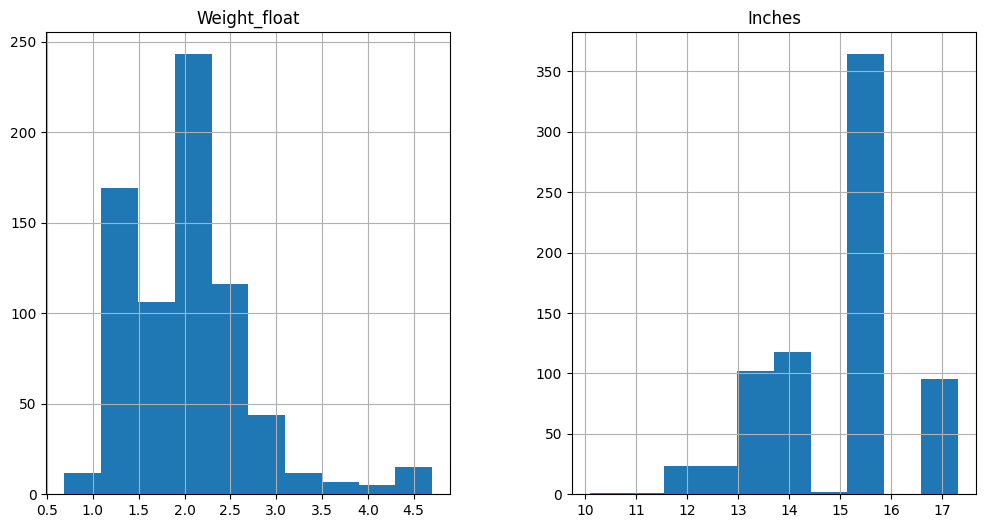

In [26]:
col_num = ["Weight_float", "Inches"]

train_set[col_num].hist(figsize=(12,6));

In [27]:
features_cat = ["Company", "Product", "TypeName", "ScreenResolution", "Cpu", "Ram_float", "Memory", "Gpu", "OpSys"]
features_num = ["Inches", "Weight_float"]
features = features_num + features_cat
target = "Price_in_euros"

### 2.2 Definir X e y


In [28]:
X_train = train_set[features]
y_train = train_set[target]
X_test = test_set[features]
y_test = test_set[target]

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

### 3.1 Transformaciones manuales

#### Ram y Weight

Estas variables ya han quedado transformadas previamente durante el análisis de los datos, eliminando "kg" a los valores de Weight y "GB" a los valores de Ram, almacenando estos datos transformados en las columnas Weight_float y Ram_float respectivamente.

#### Memory

In [29]:
import re

def process_memory(memory):

    # Inicializamos capacidades
    ssd = 0
    hdd = 0
    flash = 0
    hybrid = 0

    # Pasamos TB a GB
    memory = memory.replace("1.0TB", "1024GB")
    memory = memory.replace("1TB", "1024GB")
    memory = memory.replace("2TB", "2048GB")

    # Separamos los distintos dispositivos
    parts = memory.split("+")

    for part in parts:

        part = part.strip()

        match = re.search(r"(\d+)GB", part)

        if match:

            capacity = int(match.group(1))

            if "SSD" in part:
                ssd += capacity

            elif "HDD" in part:
                hdd += capacity

            elif "Flash Storage" in part:
                flash += capacity

            elif "Hybrid" in part:
                hybrid += capacity

    return pd.Series([ssd, hdd, flash, hybrid])

In [30]:
X_train[["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]] = (
    X_train["Memory"].apply(process_memory)
)

X_test[["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]] = (
    X_test["Memory"].apply(process_memory)
)

In [31]:
X_train[
    ["Memory", "SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]
].head(15)

,Memory,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB
25,1TB HDD,0,1024,0,0
84,512GB SSD,512,0,0,0
10,512GB SSD,512,0,0,0
342,500GB HDD,0,500,0,0
890,256GB SSD + 2TB HDD,256,2048,0,0
396,500GB HDD,0,500,0,0
744,256GB SSD,256,0,0,0
823,128GB SSD,128,0,0,0
118,256GB SSD,256,0,0,0
298,512GB SSD + 1TB HDD,512,1024,0,0


#### Cpu

In [32]:
def process_cpu(cpu):

    # Marca
    if cpu.startswith("Intel"):
        brand = "Intel"
    elif cpu.startswith("AMD"):
        brand = "AMD"
    elif cpu.startswith("Samsung"):
        brand = "Samsung"
    else:
        brand = "Other"

    # Frecuencia (GHz)
    match = re.search(r'(\d+(\.\d+)?)GHz', cpu)
    frequency = float(match.group(1)) if match else None

    # Familia
    if "Core i3" in cpu:
        family = "Core i3"
    elif "Core i5" in cpu:
        family = "Core i5"
    elif "Core i7" in cpu:
        family = "Core i7"
    elif "Core M" in cpu:
        family = "Core M"
    elif "Celeron" in cpu:
        family = "Celeron"
    elif "Pentium" in cpu:
        family = "Pentium"
    elif "Xeon" in cpu:
        family = "Xeon"
    elif "Atom" in cpu:
        family = "Atom"
    elif "Ryzen" in cpu:
        family = "Ryzen"
    elif "A-Series" in cpu:
        family = "A-Series"
    elif "A9-Series" in cpu:
        family = "A9-Series"
    elif "A10-Series" in cpu:
        family = "A10-Series"
    elif "A12-Series" in cpu:
        family = "A12-Series"
    elif "E-Series" in cpu:
        family = "E-Series"
    else:
        family = "Other"

    return pd.Series([brand, family, frequency])

In [33]:
X_train[["CPU_Brand", "CPU_Family", "CPU_Frequency"]] = (
    X_train["Cpu"].apply(process_cpu)
)

X_test[["CPU_Brand", "CPU_Family", "CPU_Frequency"]] = (
    X_test["Cpu"].apply(process_cpu)
)

In [34]:
X_train["CPU_Family"].value_counts()

CPU_Family
Core i7       299
Core i5       232
Core i3        74
Celeron        52
Pentium        23
Core M         11
Other          10
A9-Series       6
E-Series        6
Atom            6
A12-Series      5
A10-Series      2
Ryzen           2
Xeon            1
Name: count, dtype: int64

#### Screen Resolution

In [35]:
def process_resolution(resolution):

    # Touchscreen
    touchscreen = int("Touchscreen" in resolution)

    # IPS
    ips = int("IPS" in resolution)

    # Resolución
    match = re.search(r'(\d+)x(\d+)', resolution)

    if match:
        res_x = int(match.group(1))
        res_y = int(match.group(2))
    else:
        res_x = None
        res_y = None

    return pd.Series([touchscreen, ips, res_x, res_y])

In [36]:
X_train[["Touchscreen", "IPS", "Resolution_X", "Resolution_Y"]] = (
    X_train["ScreenResolution"].apply(process_resolution)
)

X_test[["Touchscreen", "IPS", "Resolution_X", "Resolution_Y"]] = (
    X_test["ScreenResolution"].apply(process_resolution)
)

#### Creacion de la variable PPI (Pixels per inch)

In [37]:
X_train["PPI"] = np.sqrt(
    X_train["Resolution_X"]**2 + X_train["Resolution_Y"]**2
) / X_train["Inches"]

X_test["PPI"] = np.sqrt(
    X_test["Resolution_X"]**2 + X_test["Resolution_Y"]**2
) / X_test["Inches"]

#### Gpu

In [38]:
def process_gpu(gpu):

    # Marca
    if gpu.startswith("Intel"):
        brand = "Intel"
    elif gpu.startswith("Nvidia"):
        brand = "Nvidia"
    elif gpu.startswith("AMD"):
        brand = "AMD"
    elif gpu.startswith("ARM"):
        brand = "ARM"
    else:
        brand = "Other"

    return pd.Series([brand])

In [39]:
X_train["GPU_Brand"] = (
    X_train["Gpu"].apply(process_gpu)
)

X_test["GPU_Brand"] = (
    X_test["Gpu"].apply(process_gpu)
)

#### Product

In [40]:
X_train["Product_Family"] = X_train["Product"].str.split().str[0]
X_test["Product_Family"] = X_test["Product"].str.split().str[0]

#### Eliminamos columnas originales de X

In [41]:
cols_to_remove = ["Memory", "Cpu", "ScreenResolution", "Gpu", "Product"]

In [42]:
X_train = X_train.drop(columns=cols_to_remove)
X_test = X_test.drop(columns=cols_to_remove)

In [43]:
X_train.head()

,Inches,Weight_float,Company,TypeName,Ram_float,OpSys,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,CPU_Brand,CPU_Family,CPU_Frequency,Touchscreen,IPS,Resolution_X,Resolution_Y,PPI,GPU_Brand,Product_Family
25,17.3,3.00,HP,Workstation,8.0,Windows 7,0,1024,0,0,Intel,Core i7,2.6,0,1,1920,1080,127.335675,AMD,ZBook
84,15.6,2.56,Dell,Gaming,16.0,Windows 10,512,0,0,0,Intel,Core i7,2.8,0,0,1920,1080,141.211998,Nvidia,Inspiron
10,13.3,1.37,Apple,Ultrabook,8.0,macOS,512,0,0,0,Intel,Core i5,2.9,0,1,2560,1600,226.983005,Intel,MacBook
342,14.0,1.54,HP,Notebook,4.0,Windows 7,0,500,0,0,Intel,Core i5,2.3,0,0,1920,1080,157.350512,Intel,EliteBook
890,17.3,2.80,Dell,Notebook,16.0,Windows 10,256,2048,0,0,Intel,Core i7,1.8,0,0,1920,1080,127.335675,AMD,Inspiron


In [44]:
X_test.head()

,Inches,Weight_float,Company,TypeName,Ram_float,OpSys,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,CPU_Brand,CPU_Family,CPU_Frequency,Touchscreen,IPS,Resolution_X,Resolution_Y,PPI,GPU_Brand,Product_Family
649,15.6,2.20,HP,Gaming,8.0,Windows 10,128,1024,0,0,Intel,Core i7,2.8,0,1,1920,1080,141.211998,Nvidia,Omen
761,15.6,2.08,Lenovo,2 in 1 Convertible,8.0,Windows 10,256,0,0,0,Intel,Core i5,2.5,1,0,1920,1080,141.211998,AMD,Yoga
545,14.0,1.87,Lenovo,Notebook,8.0,Windows 10,256,0,0,0,Intel,Core i5,2.5,0,1,1920,1080,157.350512,Nvidia,Thinkpad
367,14.0,1.63,HP,2 in 1 Convertible,4.0,Windows 10,128,0,0,0,Intel,Core i3,2.4,1,1,1920,1080,157.350512,Nvidia,Pavilion
361,15.6,2.20,Asus,Notebook,4.0,Windows 10,0,500,0,0,Intel,Celeron,1.6,0,0,1366,768,100.454670,Intel,X553SA-XX031T


### 3.2 Transformaciones con One Hot Encoder

In [45]:
cols_to_encode = ["Company", "TypeName", "OpSys", "CPU_Brand", "CPU_Family", "GPU_Brand", "Product_Family"]

In [46]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cols_to_encode])
X_test_cat = encoder.transform(X_test[cols_to_encode])

In [47]:
column_names = encoder.get_feature_names_out(cols_to_encode)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=column_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=column_names,
    index=X_test.index
)

In [48]:
X_train = X_train.drop(columns=cols_to_encode)
X_test = X_test.drop(columns=cols_to_encode)

In [49]:
X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test = pd.concat([X_test, X_test_cat], axis=1)

In [51]:
X_train.shape

(729, 221)

## 4. Modelado

### 4.1 Entrenamiento

##### Random Forest Regressor Baseline

In [231]:
rf_baseline = RandomForestRegressor(random_state=42)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)

##### XGBoost Baseline

In [232]:
xgb_baseline = XGBRegressor(random_state=42)

xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [233]:
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"RMSE Random Forest Baseline: {rmse_rf:.2f}")


rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f"RMSE XGBoost baseline: {rmse_xgb:.2f}")


RMSE Random Forest Baseline: 335.59
RMSE XGBoost baseline: 318.46


### 4.3 Optimización (up to you 🫰🏻)

##### Optimización XGBoost

In [234]:
xgb = XGBRegressor(random_state=42)

param_dist_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


In [235]:
random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [236]:
y_pred_xgb_random = random_search_xgb.predict(X_test)

rmse_rand_xgb = root_mean_squared_error(y_test, y_pred_xgb_random)

print(f"RMSE XGBoost Random Search: {rmse_rand_xgb:.2f}")

RMSE XGBoost Random Search: 285.17


In [237]:
random_search_xgb.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [238]:
xgb_2 = XGBRegressor(
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=1,
    gamma=0
)

param_grid_gs = {
    "n_estimators": [250, 300, 350],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.15]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_2,
    param_grid=param_grid_gs,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [239]:
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [250, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [241]:
grid_search_xgb.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 350}

In [240]:
y_pred_xgb_grid = grid_search_xgb.predict(X_test)

rmse_grid_xgb = root_mean_squared_error(y_test, y_pred_xgb_grid)

print(f"RMSE XGBoost Grid Search: {rmse_grid_xgb:.2f}")

RMSE XGBoost Grid Search: 276.49


##### Optimización Random Forest Regressor

In [242]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [243]:
random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [244]:
y_pred_rf_random = random_search_rf.predict(X_test)

rmse_rand_rf = root_mean_squared_error(y_test, y_pred_rf_random)

print(f"RMSE Random Forest Random Search: {rmse_rand_rf:.2f}")

RMSE Random Forest Random Search: 335.59


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [251]:
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

In [252]:
best_xgb = grid_search_xgb.best_estimator_

best_xgb.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [253]:
X_pred_original = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred = X_pred_original.copy()
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [254]:
X_pred["Ram_float"] = X_pred["Ram"].str.replace("GB", "", regex=False).astype(float)

X_pred["Weight_float"] = X_pred["Weight"].str.replace("kg", "", regex=False).astype(float)

X_pred = X_pred[features]

X_pred[["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]] = (
    X_pred["Memory"].apply(process_memory)
)

X_pred[["CPU_Brand", "CPU_Family", "CPU_Frequency"]] = (
    X_pred["Cpu"].apply(process_cpu)
)

X_pred[["Touchscreen", "IPS", "Resolution_X", "Resolution_Y"]] = (
    X_pred["ScreenResolution"].apply(process_resolution)
)

X_pred["PPI"] = np.sqrt(
    X_pred["Resolution_X"]**2 + X_pred["Resolution_Y"]**2
) / X_pred["Inches"]

X_pred["GPU_Brand"] = (
    X_pred["Gpu"].apply(process_gpu)
)

X_pred["Product_Family"] = X_pred["Product"].str.split().str[0]

X_pred = X_pred.drop(columns=cols_to_remove)


X_pred_cat = encoder.transform(X_pred[cols_to_encode])

X_pred_cat = pd.DataFrame(
    X_pred_cat,
    columns=column_names,
    index=X_pred.index
)

X_pred = X_pred.drop(columns=cols_to_encode)

X_pred = pd.concat([X_pred, X_pred_cat], axis=1)

In [255]:
print(X.columns.equals(X_pred.columns))

True


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [256]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [257]:
predicciones = best_xgb.predict(X_pred)

In [258]:
submission_xgb_grid_with_product = pd.DataFrame({
    "laptop_ID": X_pred_original["laptop_ID"],
    "Price_in_euros": predicciones
})

In [259]:
submission_xgb_grid_with_product.head()

,laptop_ID,Price_in_euros
0,209,1470.101074
1,1281,305.634796
2,1168,334.058136
3,1231,989.809082
4,1020,970.161072


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [260]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [261]:
checker(submission_xgb_grid_with_product, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260702_130131.csv'. ¡A Kaggle!
